# Notebook 06 — ABP hyperparameter sensitivity

This version targets the **refactored STAGE API** used by the repository:

- `ABPMetaDynamics(deposition_stride=..., transition_detector=..., ...)`
- `result = simulation.run(max_steps=...)`
- the returned `ABPResult` contains the trajectory, weights, deposited centers,
  transition index and reconstructed physical time.

The notebook performs reproducible parameter sweeps in \(W\) and \(\sigma\),
stores raw results incrementally, computes uncertainty and transition success
rates, and generates figures for the report and appendices.

## 1. Imports and repository paths

In [25]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
import inspect
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from joblib import Parallel, delayed
except ImportError:
    Parallel = None
    delayed = None

cwd = Path.cwd().resolve()

if (cwd / "src" / "stage_escape").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "src" / "stage_escape").exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError(
        "Could not locate the STAGE repository root. "
        "Run this notebook from STAGE/ or STAGE/notebooks/."
    )

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from stage_escape.abp_abf.abp_metadynamics import ABPMetaDynamics
from stage_escape.abp_abf.transition_detector import TransitionDetector

RESULTS_DIR = REPO_ROOT / "results" / "notebook06_hyperparameters"
FIGURES_DIR = REPO_ROOT / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("ABPMetaDynamics.__init__:", inspect.signature(ABPMetaDynamics.__init__))
print("ABPMetaDynamics.run:", inspect.signature(ABPMetaDynamics.run))
print("TransitionDetector.__init__:", inspect.signature(TransitionDetector.__init__))

Repository root: /home/administrateur/Bureau/STAGE
ABPMetaDynamics.__init__: (self, deposition_stride, transition_detector, delta_t, dimension=1, D=1.0, initial_position=None, b=None, W=0.1, sigma=0.001, seed=None, rng=None, cutoff=5.0) -> 'None'
ABPMetaDynamics.run: (self, max_steps=1000000, *, reset: 'bool' = False) -> 'ABPResult'
TransitionDetector.__init__: (self, collective_variable: 'Callable[[np.ndarray], float]', threshold: 'float', direction: 'TransitionDirection' = 'above') -> None


## 2. Potential and collective variable

The default example is a one-dimensional symmetric double well,
\[
V(x)=\frac{a}{4}(x^2-1)^2.
\]

If notebook 06 uses another potential, replace only this class and the physical
parameters in the following cell.

In [26]:
class SymmetricDoubleWellPotential:
    def __init__(self, a: float = 1.0):
        self.a = float(a)
        self.dimension = 1

    def potential_at(self, x):
        x = np.asarray(x, dtype=float)
        return self.a * 0.25 * (x**2 - 1.0)**2

    def potential_prime_at(self, x):
        x = np.asarray(x, dtype=float)
        return self.a * x * (x**2 - 1.0)


def reaction_coordinate_x(position) -> float:
    x = np.asarray(position, dtype=float).reshape(-1)
    return float(x[0])

## 3. Numerical parameters

`DEPOSITION_STRIDE` is the number of integration steps between two Gaussian
depositions. `MAX_STEPS` is the total integration-step budget for one
realization.

In [27]:
D = 1.0
DELTA_T = 1e-3
INITIAL_POSITION = np.array([-1.0])
TRANSITION_THRESHOLD = 0.80
POTENTIAL_AMPLITUDE = 1.0

DEPOSITION_STRIDE = 20
MAX_STEPS = 40_000

N_REPLICAS = 10
N_JOBS = -1
BASE_SEED = 20260812

# W sensitivity
N_W_VALUES = 18
W_VALUES = np.geomspace(1e-1, 1, N_W_VALUES)
SIGMA_FIXED_FOR_W = 0.10

# sigma sensitivity
N_SIGMA_VALUES = 30
SIGMA_VALUES = np.geomspace(1e-5, 0.2, N_SIGMA_VALUES)
W_FIXED_FOR_SIGMA = 0.30

potential = SymmetricDoubleWellPotential(a=POTENTIAL_AMPLITUDE)

## 4. One ABP realization using the refactored API

No subclassing of `ABPMetaDynamics` is needed.

For every realization:

1. construct a fresh `TransitionDetector`;
2. construct `ABPMetaDynamics` with `deposition_stride`;
3. call `run(max_steps=...)`;
4. obtain the transition index and physical time from the returned result.

The biased transition time is reconstructed as
\[
t_{\mathrm{biased}} = n_{\mathrm{transition}}\Delta t,
\]
while the physical time is the reweighted time returned by the ABP result.

In [28]:
@dataclass
class ABPRunResult:
    parameter_name: str
    parameter_value: float
    replica: int
    seed: int
    success: bool
    physical_time: float
    biased_time: float
    acceleration_factor: float
    integration_steps: int
    n_deposited_gaussians: int
    W: float
    sigma: float


def build_transition_detector():
    return TransitionDetector(
        collective_variable=reaction_coordinate_x,
        threshold=TRANSITION_THRESHOLD,
        direction="above",
    )


def run_abp_once(
    *,
    parameter_name: str,
    parameter_value: float,
    replica: int,
    seed: int,
    W: float,
    sigma: float,
) -> ABPRunResult:

    detector = build_transition_detector()

    simulation = ABPMetaDynamics(
        deposition_stride=DEPOSITION_STRIDE,
        transition_detector=detector,
        delta_t=DELTA_T,
        dimension=1,
        D=D,
        initial_position=INITIAL_POSITION.copy(),
        b=potential,
        W=float(W),
        sigma=float(sigma),
        seed=int(seed),
    )

    result = simulation.run(max_steps=MAX_STEPS)

    transition_index = result.transition_index
    success = transition_index is not None

    if success:
        integration_steps = int(transition_index)
        biased_time = integration_steps * DELTA_T
        physical_time = float(result.physical_time)

        acceleration_factor = (
            physical_time / biased_time
            if biased_time > 0.0
            else np.nan
        )
    else:
        integration_steps = max(0, len(result.positions) - 1)
        biased_time = integration_steps * DELTA_T
        physical_time = float(result.physical_time)
        acceleration_factor = np.nan

    n_deposited_gaussians = len(result.centers)

    return ABPRunResult(
        parameter_name=parameter_name,
        parameter_value=float(parameter_value),
        replica=int(replica),
        seed=int(seed),
        success=bool(success),
        physical_time=float(physical_time),
        biased_time=float(biased_time),
        acceleration_factor=float(acceleration_factor),
        integration_steps=int(integration_steps),
        n_deposited_gaussians=int(n_deposited_gaussians),
        W=float(W),
        sigma=float(sigma),
    )

## 5. Quick compatibility test

Run this cell **before launching the full sweep**. It performs one short ABP
realization and immediately exposes any remaining API mismatch.

In [29]:
test_result = run_abp_once(
    parameter_name="W",
    parameter_value=float(W_VALUES[0]),
    replica=0,
    seed=BASE_SEED,
    W=float(W_VALUES[0]),
    sigma=SIGMA_FIXED_FOR_W,
)

print(test_result)

ABPRunResult(parameter_name='W', parameter_value=0.1, replica=0, seed=20260812, success=True, physical_time=1.2102424707600254, biased_time=0.811, acceleration_factor=1.4922841809618068, integration_steps=811, n_deposited_gaussians=40, W=0.1, sigma=0.1)


## 6. Resumable sweep engine

Results are written to CSV after every completed parameter value. If the kernel
is interrupted, rerun the sweep cell; already completed replicas are skipped.

In [30]:
def make_seed(parameter_index: int, replica: int, sweep_offset: int) -> int:
    sequence = np.random.SeedSequence(
        [BASE_SEED, sweep_offset, parameter_index, replica]
    )
    return int(sequence.generate_state(1, dtype=np.uint32)[0])


def execute_jobs(jobs):
    if Parallel is None or N_JOBS == 1:
        return [run_abp_once(**job) for job in jobs]

    return Parallel(n_jobs=N_JOBS, verbose=0)(
        delayed(run_abp_once)(**job)
        for job in jobs
    )


def run_parameter_sweep(
    *,
    parameter_name: str,
    values,
    fixed_W: float | None,
    fixed_sigma: float | None,
    csv_path: Path,
    sweep_offset: int,
) -> pd.DataFrame:

    values = np.asarray(values, dtype=float)

    if csv_path.exists():
        existing = pd.read_csv(csv_path)
    else:
        existing = pd.DataFrame()

    completed = set()

    if not existing.empty:
        for row in existing.itertuples():
            completed.add(
                (
                    round(float(row.parameter_value), 15),
                    int(row.replica),
                )
            )

    accumulated_new_rows = []

    for parameter_index, value in enumerate(values):

        jobs = []

        for replica in range(N_REPLICAS):
            key = (round(float(value), 15), replica)

            if key in completed:
                continue

            W = float(value) if parameter_name == "W" else float(fixed_W)
            sigma = (
                float(value)
                if parameter_name == "sigma"
                else float(fixed_sigma)
            )

            jobs.append(
                dict(
                    parameter_name=parameter_name,
                    parameter_value=float(value),
                    replica=replica,
                    seed=make_seed(
                        parameter_index,
                        replica,
                        sweep_offset,
                    ),
                    W=W,
                    sigma=sigma,
                )
            )

        if not jobs:
            continue

        print(
            f"{parameter_name} = {value:.6g}: "
            f"running {len(jobs)} missing replica(s)"
        )

        results = execute_jobs(jobs)
        accumulated_new_rows.extend(asdict(result) for result in results)

        new_df = pd.DataFrame(accumulated_new_rows)

        combined = pd.concat(
            [existing, new_df],
            ignore_index=True,
        )

        combined = (
            combined
            .drop_duplicates(
                subset=[
                    "parameter_name",
                    "parameter_value",
                    "replica",
                ],
                keep="last",
            )
            .sort_values(
                ["parameter_value", "replica"]
            )
        )

        combined.to_csv(csv_path, index=False)

    if csv_path.exists():
        final = pd.read_csv(csv_path)
    else:
        final = pd.DataFrame(accumulated_new_rows)

    return (
        final
        .sort_values(["parameter_value", "replica"])
        .reset_index(drop=True)
    )

## 7. \(W\) sweep

In [31]:
W_CSV = RESULTS_DIR / "sweep_W.csv"

results_W = run_parameter_sweep(
    parameter_name="W",
    values=W_VALUES,
    fixed_W=None,
    fixed_sigma=SIGMA_FIXED_FOR_W,
    csv_path=W_CSV,
    sweep_offset=100,
)

display(results_W.head())
print(
    f"Stored rows: {len(results_W)} / "
    f"{len(W_VALUES) * N_REPLICAS}"
)

W = 0.1: running 10 missing replica(s)
W = 0.114505: running 10 missing replica(s)
W = 0.131113: running 10 missing replica(s)
W = 0.150131: running 10 missing replica(s)
W = 0.171907: running 10 missing replica(s)
W = 0.196842: running 10 missing replica(s)
W = 0.225393: running 10 missing replica(s)
W = 0.258086: running 10 missing replica(s)
W = 0.295521: running 10 missing replica(s)
W = 0.338386: running 10 missing replica(s)
W = 0.387468: running 10 missing replica(s)
W = 0.443669: running 10 missing replica(s)
W = 0.508022: running 10 missing replica(s)
W = 0.581709: running 10 missing replica(s)
W = 0.666085: running 10 missing replica(s)
W = 0.762699: running 10 missing replica(s)
W = 0.873326: running 10 missing replica(s)
W = 1: running 10 missing replica(s)


,parameter_name,parameter_value,replica,seed,success,physical_time,biased_time,acceleration_factor,integration_steps,n_deposited_gaussians,W,sigma
0,W,0.1,0,153284671,True,116.982279,7.299,16.027165,7299,364,0.1,0.1
1,W,0.1,1,2730575750,True,12.007920,3.757,3.196146,3757,187,0.1,0.1
2,W,0.1,2,3923090481,True,5.482910,2.436,2.250784,2436,121,0.1,0.1
3,W,0.1,3,3006209436,True,7.163644,2.897,2.472780,2897,144,0.1,0.1
4,W,0.1,4,2658898818,True,9.028655,3.180,2.839200,3180,158,0.1,0.1


Stored rows: 180 / 180


## 8. \(\sigma\) sweep

In [32]:
SIGMA_CSV = RESULTS_DIR / "sweep_sigma.csv"

results_sigma = run_parameter_sweep(
    parameter_name="sigma",
    values=SIGMA_VALUES,
    fixed_W=W_FIXED_FOR_SIGMA,
    fixed_sigma=None,
    csv_path=SIGMA_CSV,
    sweep_offset=200,
)

display(results_sigma.head())
print(
    f"Stored rows: {len(results_sigma)} / "
    f"{len(SIGMA_VALUES) * N_REPLICAS}"
)

sigma = 1e-05: running 10 missing replica(s)
sigma = 1.40706e-05: running 10 missing replica(s)
sigma = 1.97981e-05: running 10 missing replica(s)
sigma = 2.7857e-05: running 10 missing replica(s)
sigma = 3.91963e-05: running 10 missing replica(s)
sigma = 5.51514e-05: running 10 missing replica(s)
sigma = 7.76012e-05: running 10 missing replica(s)
sigma = 0.000109189: running 10 missing replica(s)
sigma = 0.000153635: running 10 missing replica(s)
sigma = 0.000216173: running 10 missing replica(s)
sigma = 0.000304168: running 10 missing replica(s)
sigma = 0.000427982: running 10 missing replica(s)
sigma = 0.000602194: running 10 missing replica(s)
sigma = 0.000847321: running 10 missing replica(s)
sigma = 0.00119223: running 10 missing replica(s)
sigma = 0.00167753: running 10 missing replica(s)
sigma = 0.00236038: running 10 missing replica(s)
sigma = 0.00332119: running 10 missing replica(s)
sigma = 0.0046731: running 10 missing replica(s)
sigma = 0.00657531: running 10 missing repli

,parameter_name,parameter_value,replica,seed,success,physical_time,biased_time,acceleration_factor,integration_steps,n_deposited_gaussians,W,sigma
0,sigma,0.00001,0,1929776942,True,1.366000,1.366,1.000000,1366,68,0.3,0.00001
1,sigma,0.00001,1,2265548563,True,1.119000,1.119,1.000000,1119,55,0.3,0.00001
2,sigma,0.00001,2,214490352,True,2.068034,2.068,1.000016,2068,103,0.3,0.00001
3,sigma,0.00001,3,1799337411,True,0.695000,0.695,1.000000,695,34,0.3,0.00001
4,sigma,0.00001,4,3124528864,True,1.090411,1.090,1.000377,1090,54,0.3,0.00001


Stored rows: 300 / 300


## 9. Statistical summaries

Means and SEMs for transition quantities are computed on successful
realizations only. `success_rate` always uses all realizations.

In [33]:
def sem(series: pd.Series) -> float:
    values = (
        pd.to_numeric(series, errors="coerce")
        .dropna()
        .to_numpy(dtype=float)
    )

    if len(values) <= 1:
        return np.nan

    return float(
        np.std(values, ddof=1) / np.sqrt(len(values))
    )


def successful_mask(df: pd.DataFrame) -> pd.Series:
    if df["success"].dtype == bool:
        return df["success"]

    return (
        df["success"]
        .astype(str)
        .str.lower()
        .isin(["true", "1"])
    )


def summarize_sweep(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for value, group in df.groupby("parameter_value", sort=True):

        successful = group[successful_mask(group)]

        row = {
            "parameter_value": float(value),
            "n_total": int(len(group)),
            "n_success": int(len(successful)),
            "success_rate": (
                len(successful) / len(group)
                if len(group)
                else np.nan
            ),
        }

        for metric in [
            "physical_time",
            "biased_time",
            "acceleration_factor",
            "integration_steps",
            "n_deposited_gaussians",
        ]:
            values = pd.to_numeric(
                successful[metric],
                errors="coerce",
            )

            row[f"{metric}_mean"] = (
                float(values.mean())
                if len(values)
                else np.nan
            )
            row[f"{metric}_sem"] = sem(values)

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values("parameter_value")
        .reset_index(drop=True)
    )


summary_W = summarize_sweep(results_W)
summary_sigma = summarize_sweep(results_sigma)

summary_W.to_csv(
    RESULTS_DIR / "summary_W.csv",
    index=False,
)
summary_sigma.to_csv(
    RESULTS_DIR / "summary_sigma.csv",
    index=False,
)

display(summary_W)
display(summary_sigma)

,parameter_value,n_total,n_success,success_rate,physical_time_mean,physical_time_sem,biased_time_mean,biased_time_sem,acceleration_factor_mean,acceleration_factor_sem,integration_steps_mean,integration_steps_sem,n_deposited_gaussians_mean,n_deposited_gaussians_sem
0,0.100000,10,10,1.0,21.202644,11.297217,3.2216,0.638957,4.274198,1.423104,3221.6,638.957105,160.4,31.942727
1,0.114505,10,10,1.0,6.180320,2.729729,1.7109,0.442419,2.434260,0.535758,1710.9,442.419370,85.0,22.107817
2,0.131113,10,10,1.0,11.680298,4.680525,2.4272,0.490196,3.445794,0.792583,2427.2,490.196147,120.9,24.486482
3,0.150131,10,10,1.0,7.574069,3.717154,1.6542,0.362092,3.142570,0.796143,1654.2,362.091603,82.3,18.132874
4,0.171907,10,10,1.0,10.286057,3.379054,1.9164,0.365677,4.014208,0.810003,1916.4,365.676639,95.3,18.290890
5,0.196842,10,10,1.0,15.050735,7.247312,1.6123,0.397795,5.498269,1.862438,1612.3,397.794868,80.1,19.851364
6,0.225393,10,10,1.0,11.132205,4.697333,1.6266,0.251876,5.162291,1.530252,1626.6,251.875904,80.7,12.543303
7,0.258086,10,10,1.0,15.577048,8.822771,1.4809,0.251016,6.793913,2.564878,1480.9,251.016443,73.5,12.600044
8,0.295521,10,10,1.0,9.299731,3.787611,1.3077,0.214111,5.412565,1.341806,1307.7,214.111085,64.7,10.658382
9,0.338386,10,10,1.0,19.321201,7.266897,1.5668,0.238277,9.297597,2.513750,1566.8,238.276627,77.8,11.943199


,parameter_value,n_total,n_success,success_rate,physical_time_mean,physical_time_sem,biased_time_mean,biased_time_sem,acceleration_factor_mean,acceleration_factor_sem,integration_steps_mean,integration_steps_sem,n_deposited_gaussians_mean,n_deposited_gaussians_sem
0,0.000010,10,10,1.0,0.989827,0.153785,0.9897,0.153790,1.000163,0.000074,989.7,153.790265,49.0,7.710022
1,0.000014,10,10,1.0,1.300220,0.139124,1.3000,0.139053,1.000144,0.000051,1300.0,139.053067,64.6,7.005078
2,0.000020,10,10,1.0,0.842582,0.194635,0.8423,0.194586,1.000731,0.000454,842.3,194.586059,41.7,9.729737
3,0.000028,10,10,1.0,0.804503,0.159940,0.8042,0.159872,1.000393,0.000098,804.2,159.872366,39.8,8.003888
4,0.000039,10,10,1.0,1.069183,0.314152,1.0689,0.314059,1.000331,0.000103,1068.9,314.058963,52.9,15.737747
5,0.000055,10,10,1.0,0.674209,0.086203,0.6737,0.086130,1.000779,0.000154,673.7,86.130012,33.3,4.341147
6,0.000078,10,10,1.0,0.627350,0.171876,0.6267,0.171617,1.002472,0.001263,626.7,171.617278,30.8,8.577490
7,0.000109,10,10,1.0,1.330138,0.211971,1.3283,0.211486,1.001243,0.000169,1328.3,211.485594,65.9,10.568770
8,0.000154,10,10,1.0,0.697041,0.190980,0.6960,0.190706,1.001618,0.000213,696.0,190.705940,34.2,9.492453
9,0.000216,10,10,1.0,0.940985,0.181277,0.9385,0.180512,1.002366,0.000280,938.5,180.512065,46.4,8.995307


## 10. Main report figure

This is the compact figure recommended for the body of the report.

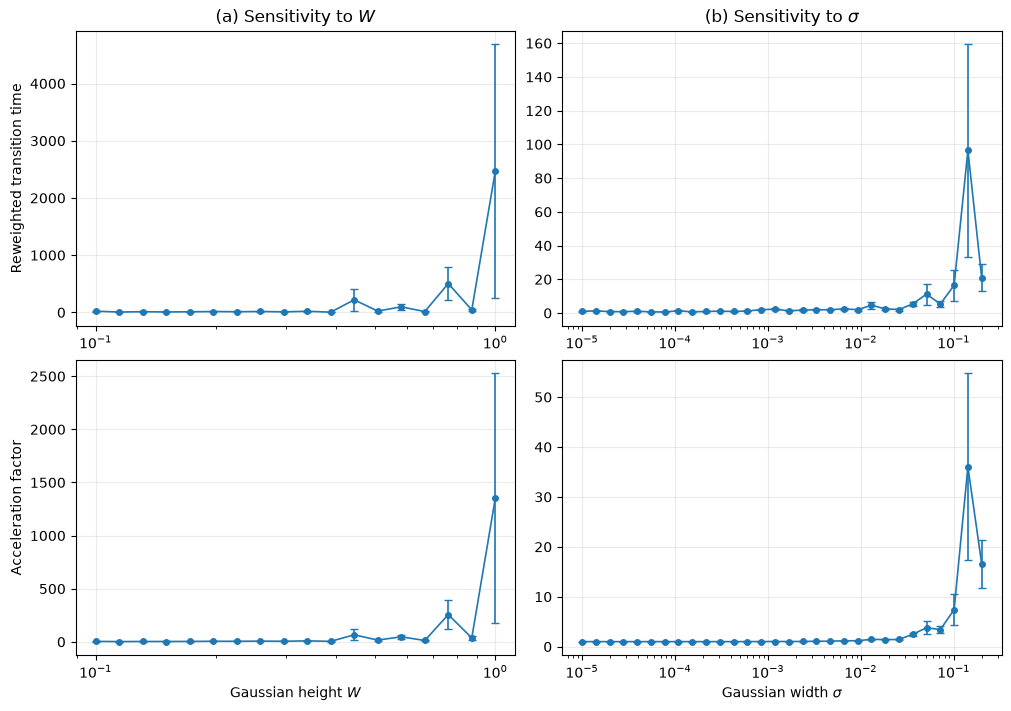

Saved: /home/administrateur/Bureau/STAGE/figures/06_abp_hyperparameter_sensitivity.pdf
Saved: /home/administrateur/Bureau/STAGE/figures/06_abp_hyperparameter_sensitivity.png


In [34]:
def plot_report_sensitivity(summary_W, summary_sigma):

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(10.0, 7.0),
        constrained_layout=True,
    )

    axes[0, 0].errorbar(
        summary_W["parameter_value"],
        summary_W["physical_time_mean"],
        yerr=summary_W["physical_time_sem"],
        marker="o",
        markersize=4,
        linewidth=1.2,
        capsize=3,
    )
    axes[0, 0].set_xscale("log")
    axes[0, 0].set_ylabel("Reweighted transition time")
    axes[0, 0].set_title(r"(a) Sensitivity to $W$")
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].errorbar(
        summary_sigma["parameter_value"],
        summary_sigma["physical_time_mean"],
        yerr=summary_sigma["physical_time_sem"],
        marker="o",
        markersize=4,
        linewidth=1.2,
        capsize=3,
    )
    axes[0, 1].set_xscale("log")
    axes[0, 1].set_title(r"(b) Sensitivity to $\sigma$")
    axes[0, 1].grid(alpha=0.25)

    axes[1, 0].errorbar(
        summary_W["parameter_value"],
        summary_W["acceleration_factor_mean"],
        yerr=summary_W["acceleration_factor_sem"],
        marker="o",
        markersize=4,
        linewidth=1.2,
        capsize=3,
    )
    axes[1, 0].set_xscale("log")
    axes[1, 0].set_xlabel(r"Gaussian height $W$")
    axes[1, 0].set_ylabel("Acceleration factor")
    axes[1, 0].grid(alpha=0.25)

    axes[1, 1].errorbar(
        summary_sigma["parameter_value"],
        summary_sigma["acceleration_factor_mean"],
        yerr=summary_sigma["acceleration_factor_sem"],
        marker="o",
        markersize=4,
        linewidth=1.2,
        capsize=3,
    )
    axes[1, 1].set_xscale("log")
    axes[1, 1].set_xlabel(r"Gaussian width $\sigma$")
    axes[1, 1].grid(alpha=0.25)

    pdf_path = FIGURES_DIR / "06_abp_hyperparameter_sensitivity.pdf"
    png_path = FIGURES_DIR / "06_abp_hyperparameter_sensitivity.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")

    return fig, pdf_path, png_path


fig, pdf_path, png_path = plot_report_sensitivity(
    summary_W,
    summary_sigma,
)

plt.show()

print("Saved:", pdf_path)
print("Saved:", png_path)

## 11. Appendix diagnostics

Each appendix figure shows:

1. physical transition time;
2. acceleration factor;
3. computational effort;
4. success rate.

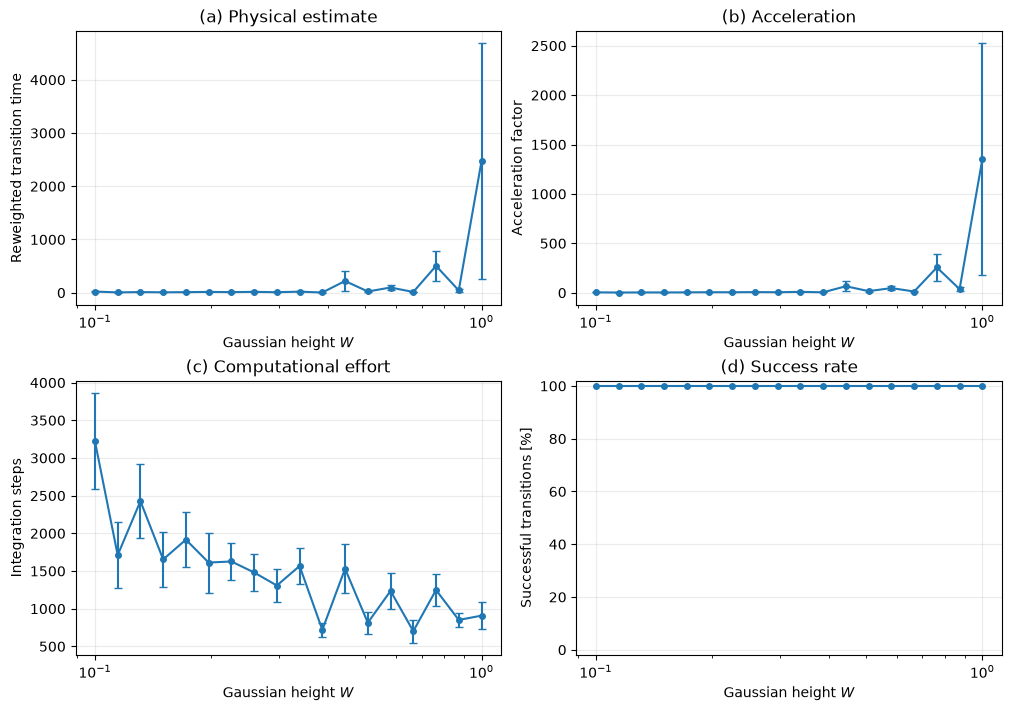

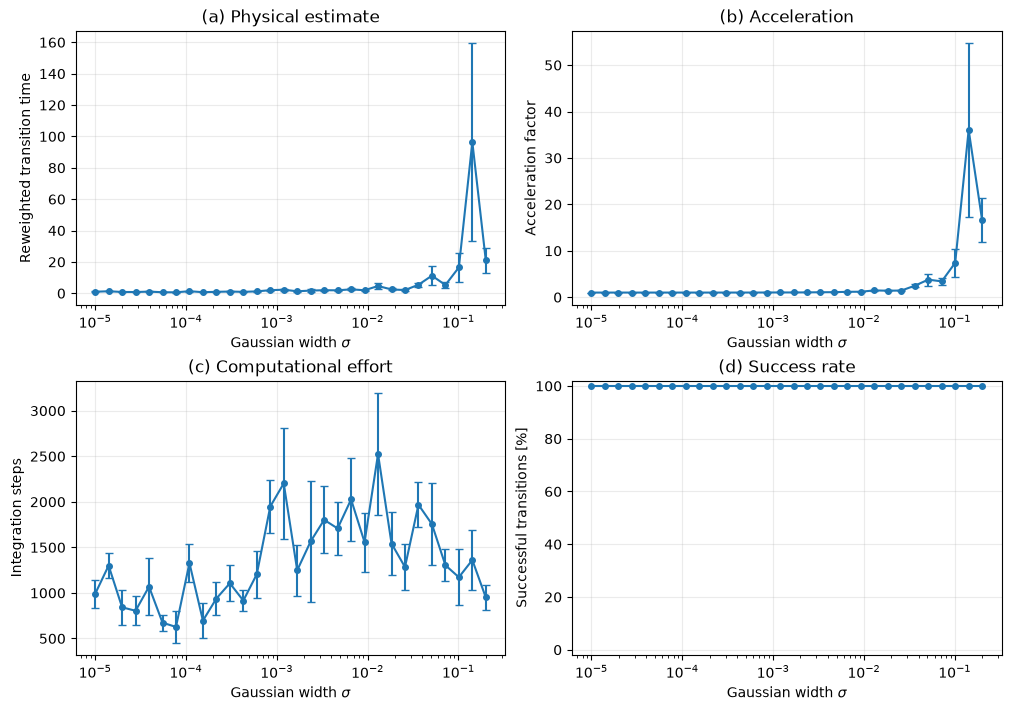

Saved: /home/administrateur/Bureau/STAGE/figures/appendix_06_W_full_diagnostics.pdf
Saved: /home/administrateur/Bureau/STAGE/figures/appendix_06_sigma_full_diagnostics.pdf


In [35]:
def plot_full_diagnostics(
    summary,
    parameter_label,
    filename_stem,
):

    x = summary["parameter_value"].to_numpy(dtype=float)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(10.0, 7.0),
        constrained_layout=True,
    )

    axes[0, 0].errorbar(
        x,
        summary["physical_time_mean"],
        yerr=summary["physical_time_sem"],
        marker="o",
        markersize=4,
        capsize=3,
    )
    axes[0, 0].set_ylabel("Reweighted transition time")
    axes[0, 0].set_title("(a) Physical estimate")
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].errorbar(
        x,
        summary["acceleration_factor_mean"],
        yerr=summary["acceleration_factor_sem"],
        marker="o",
        markersize=4,
        capsize=3,
    )
    axes[0, 1].set_ylabel("Acceleration factor")
    axes[0, 1].set_title("(b) Acceleration")
    axes[0, 1].grid(alpha=0.25)

    axes[1, 0].errorbar(
        x,
        summary["integration_steps_mean"],
        yerr=summary["integration_steps_sem"],
        marker="o",
        markersize=4,
        capsize=3,
    )
    axes[1, 0].set_ylabel("Integration steps")
    axes[1, 0].set_title("(c) Computational effort")
    axes[1, 0].grid(alpha=0.25)

    axes[1, 1].plot(
        x,
        100.0 * summary["success_rate"],
        marker="o",
        markersize=4,
    )
    axes[1, 1].set_ylim(-2, 102)
    axes[1, 1].set_ylabel("Successful transitions [%]")
    axes[1, 1].set_title("(d) Success rate")
    axes[1, 1].grid(alpha=0.25)

    for ax in axes.flat:
        ax.set_xscale("log")
        ax.set_xlabel(parameter_label)

    pdf_path = FIGURES_DIR / f"{filename_stem}.pdf"
    png_path = FIGURES_DIR / f"{filename_stem}.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")

    return fig, pdf_path, png_path


fig_W, W_pdf, W_png = plot_full_diagnostics(
    summary_W,
    r"Gaussian height $W$",
    "appendix_06_W_full_diagnostics",
)
plt.show()

fig_sigma, sigma_pdf, sigma_png = plot_full_diagnostics(
    summary_sigma,
    r"Gaussian width $\sigma$",
    "appendix_06_sigma_full_diagnostics",
)
plt.show()

print("Saved:", W_pdf)
print("Saved:", sigma_pdf)

## 12. Quality checks

These flags are interpretation aids, not universal thresholds.

In [36]:
def quality_check(summary, name):

    checked = summary.copy()

    checked["relative_sem_physical_time"] = (
        checked["physical_time_sem"]
        / checked["physical_time_mean"]
    )

    checked["flag_low_success"] = (
        checked["success_rate"] < 0.50
    )
    checked["flag_too_few_successes"] = (
        checked["n_success"] < 3
    )
    checked["flag_large_relative_sem"] = (
        checked["relative_sem_physical_time"] > 0.30
    )

    flags = [
        "flag_low_success",
        "flag_too_few_successes",
        "flag_large_relative_sem",
    ]

    flagged = checked[
        checked[flags].any(axis=1)
    ]

    print(
        f"{name}: {len(flagged)} flagged parameter value(s)"
    )

    return flagged


display(quality_check(summary_W, "W sweep"))
display(quality_check(summary_sigma, "sigma sweep"))

W sweep: 18 flagged parameter value(s)


,parameter_value,n_total,n_success,success_rate,physical_time_mean,physical_time_sem,biased_time_mean,biased_time_sem,acceleration_factor_mean,acceleration_factor_sem,integration_steps_mean,integration_steps_sem,n_deposited_gaussians_mean,n_deposited_gaussians_sem,relative_sem_physical_time,flag_low_success,flag_too_few_successes,flag_large_relative_sem
0,0.100000,10,10,1.0,21.202644,11.297217,3.2216,0.638957,4.274198,1.423104,3221.6,638.957105,160.4,31.942727,0.532821,False,False,True
1,0.114505,10,10,1.0,6.180320,2.729729,1.7109,0.442419,2.434260,0.535758,1710.9,442.419370,85.0,22.107817,0.441681,False,False,True
2,0.131113,10,10,1.0,11.680298,4.680525,2.4272,0.490196,3.445794,0.792583,2427.2,490.196147,120.9,24.486482,0.400720,False,False,True
3,0.150131,10,10,1.0,7.574069,3.717154,1.6542,0.362092,3.142570,0.796143,1654.2,362.091603,82.3,18.132874,0.490774,False,False,True
4,0.171907,10,10,1.0,10.286057,3.379054,1.9164,0.365677,4.014208,0.810003,1916.4,365.676639,95.3,18.290890,0.328508,False,False,True
5,0.196842,10,10,1.0,15.050735,7.247312,1.6123,0.397795,5.498269,1.862438,1612.3,397.794868,80.1,19.851364,0.481525,False,False,True
6,0.225393,10,10,1.0,11.132205,4.697333,1.6266,0.251876,5.162291,1.530252,1626.6,251.875904,80.7,12.543303,0.421959,False,False,True
7,0.258086,10,10,1.0,15.577048,8.822771,1.4809,0.251016,6.793913,2.564878,1480.9,251.016443,73.5,12.600044,0.566396,False,False,True
8,0.295521,10,10,1.0,9.299731,3.787611,1.3077,0.214111,5.412565,1.341806,1307.7,214.111085,64.7,10.658382,0.407282,False,False,True
9,0.338386,10,10,1.0,19.321201,7.266897,1.5668,0.238277,9.297597,2.513750,1566.8,238.276627,77.8,11.943199,0.376110,False,False,True


sigma sweep: 7 flagged parameter value(s)


,parameter_value,n_total,n_success,success_rate,physical_time_mean,physical_time_sem,biased_time_mean,biased_time_sem,acceleration_factor_mean,acceleration_factor_sem,integration_steps_mean,integration_steps_sem,n_deposited_gaussians_mean,n_deposited_gaussians_sem,relative_sem_physical_time,flag_low_success,flag_too_few_successes,flag_large_relative_sem
16,0.002360,10,10,1.0,1.718972,0.782219,1.5661,0.666325,1.039327,0.015337,1566.1,666.324970,77.9,33.346481,0.455050,False,False,True
21,0.013018,10,10,1.0,4.642000,2.074871,2.5255,0.667490,1.467269,0.157494,2525.5,667.490429,125.8,33.343932,0.446978,False,False,True
25,0.051025,10,10,1.0,11.234583,6.262616,1.7551,0.450365,3.787692,1.281193,1755.1,450.364703,87.2,22.526922,0.557441,False,False,True
26,0.071795,10,10,1.0,5.297641,1.709837,1.3044,0.177948,3.413470,0.701385,1304.4,177.948195,64.7,8.884506,0.322754,False,False,True
27,0.101020,10,10,1.0,16.476414,9.135130,1.1723,0.307727,7.410640,3.072314,1172.3,307.727443,58.2,15.395382,0.554437,False,False,True
28,0.142141,10,10,1.0,96.459745,63.010408,1.3614,0.332005,36.040001,18.695096,1361.4,332.005395,67.5,16.577930,0.653230,False,False,True
29,0.200000,10,10,1.0,20.915435,8.019362,0.9500,0.133139,16.584253,4.782729,950.0,133.138858,46.9,6.654071,0.383418,False,False,True


## Files generated

Main report:

- `figures/06_abp_hyperparameter_sensitivity.pdf`

Appendices:

- `figures/appendix_06_W_full_diagnostics.pdf`
- `figures/appendix_06_sigma_full_diagnostics.pdf`

Raw and summarized data are stored under:

- `results/notebook06_hyperparameters/`